In [1]:
!pip install pandas torch transformers tensorflow


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  ADBL Stock Prediction with FinBERT Sentiment

[Setup] Checking files...
  Looking in: D:\Minor\spa\python\STOCKNEPSE\NEPSEDATA
  Stock file: adbl.csv ... ✓ FOUND
  News file:  adblnewshtml.csv ... ✓ FOUND
  ✓ All files found!

[1/7] Loading FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Ready

[2/7] Loading news from adblnewshtml.csv...
  ✓ Loaded 496 articles
  Columns: ['Date', 'Headline', 'Link']

  Detected: Date=Date, Title=Headline, Content=None

[3/7] Running FinBERT on each article...
  ✓ Analyzed 496 articles

                                                                Headline Prediction  Sentiment_Score
0                     Bonus Shares of ADBL, ALBSL, SHIVM listed in NEPSE    neutral         0.000000
1  Falgun Interest Rate Update: Commercial Banks Revise Fixed Deposit...    neutral         0.000000
2  Commercial Banks Revise Magh Interest Rates; HBL and  MBL Leads wi...   positive         0.913054
3  Commercial Banks Revise Poush Interest Rates; GBIME, PCBL and RBBL...   positive         0.884442
4  NRB Report Highlights Commercial and Development Banks' Net Profit...   positive         0.604346
5         Reminder! Last Trading Day to Secure Dividend of Six Companies    neutral         0.000000
6  Agricultural Development Bank Unveils Book Closur

  ✓ Saved → adbl_lstm_model.h5

  EVALUATION & PREDICTION

RMSE: 6.9956 NPR



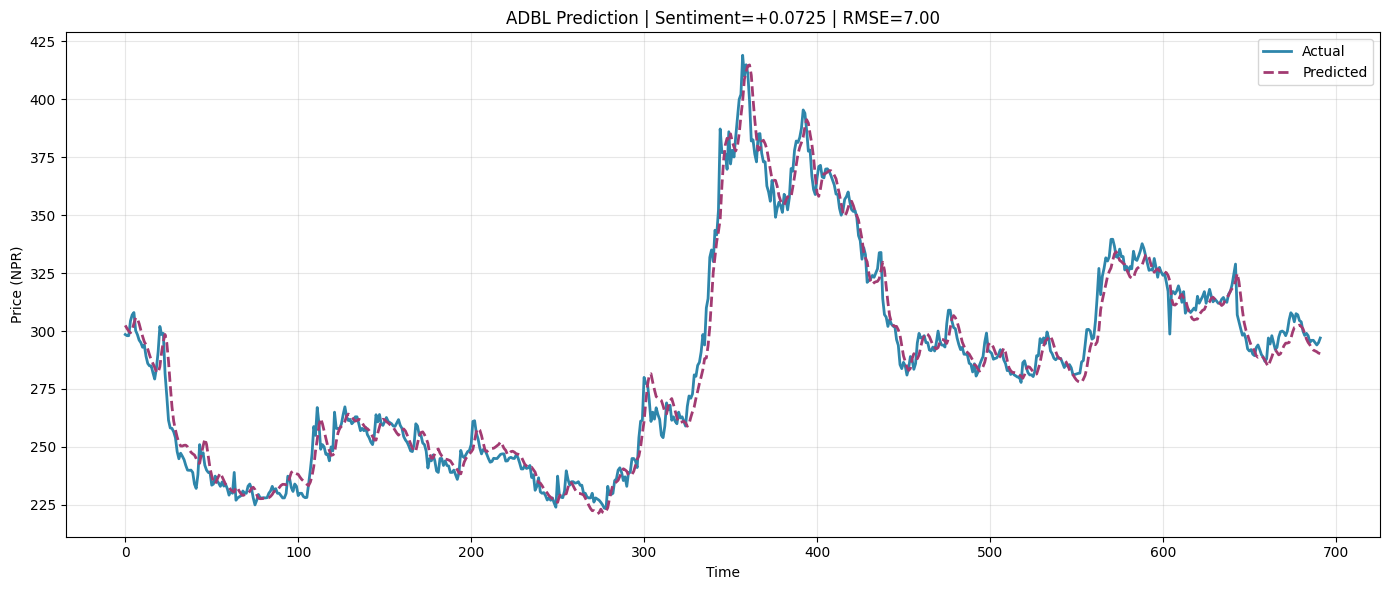

✓ Plot saved

  PREDICTION SUMMARY
  Current:   NPR 297.00
  Predicted: NPR 290.28018
  Change:    -2.26% ▼ DOWN
  Sentiment: +0.072464 (positive)
  RMSE:      6.9956


UnicodeEncodeError: 'charmap' codec can't encode character '\u25bc' in position 18: character maps to <undefined>

In [7]:
"""
ADBL Stock Price Prediction - Notebook Version
================================================
Just update the file paths below to match YOUR files!
"""

# ══════════════════════════════════════════════════════════════════════════════
# ⚠️ IMPORTANT: UPDATE THESE PATHS TO MATCH YOUR FILES ⚠️
# ══════════════════════════════════════════════════════════════════════════════

# Where are your files? (use forward slashes or double backslashes)
DATA_DIR = "STOCKNEPSE/NEPSEDATA"  # ← change this to your folder

# What are your files called? (check the folder to see exact names)
STOCK_FILE = "adbl.csv"                    # ← stock prices
NEWS_FILE  = "adblnewshtml.csv"           # ← news articles (UPDATE THIS!)

# Other settings
MODEL_FILE = "adbl_lstm_model.h5"
TIME_STEPS = 60
EPOCHS     = 50
BATCH_SIZE = 32

# ══════════════════════════════════════════════════════════════════════════════
# DON'T EDIT BELOW THIS LINE
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

print("=" * 70)
print("  ADBL Stock Prediction with FinBERT Sentiment")
print("=" * 70)
print()

# ── File Check ────────────────────────────────────────────────────────────────
print("[Setup] Checking files...")
import os

# Convert to Path objects
stock_path = Path(DATA_DIR) / STOCK_FILE
news_path  = Path(DATA_DIR) / NEWS_FILE

print(f"  Looking in: {Path(DATA_DIR).absolute()}")
print(f"  Stock file: {STOCK_FILE} ... ", end="")
if stock_path.exists():
    print("✓ FOUND")
else:
    print("✗ NOT FOUND")
    
print(f"  News file:  {NEWS_FILE} ... ", end="")
if news_path.exists():
    print("✓ FOUND")
else:
    print("✗ NOT FOUND")

if not stock_path.exists() or not news_path.exists():
    print()
    print("  ✗ ERROR: Files not found!")
    print()
    print("  Available CSV files in that folder:")
    try:
        for f in os.listdir(DATA_DIR):
            if f.endswith('.csv'):
                print(f"    • {f}")
    except:
        print("    (folder not accessible)")
    print()
    print("  Solutions:")
    print("    1. Update DATA_DIR to the correct folder path")
    print("    2. Update STOCK_FILE and NEWS_FILE to match your filenames")
    raise FileNotFoundError(f"Required files not found in {DATA_DIR}")

print("  ✓ All files found!\n")


# ── Load FinBERT ──────────────────────────────────────────────────────────────
print("[1/7] Loading FinBERT...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
finbert   = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer,
               truncation=True, max_length=512, top_k=None)
print("  ✓ Ready\n")


# ── Helper Functions ──────────────────────────────────────────────────────────
def get_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return None
    
    raw = nlp(text.strip())
    result = raw[0] if isinstance(raw[0], list) else raw
    if not isinstance(result[0], dict):
        return None

    scores = {r["label"]: r["score"] for r in result}
    neu = scores.get("neutral",  0.0)
    neg = scores.get("negative", 0.0)
    pos = scores.get("positive", 0.0)

    label = max({"positive": pos, "negative": neg, "neutral": neu},
                key=lambda k: {"positive": pos, "negative": neg, "neutral": neu}[k])
    
    score = pos if label == "positive" else (-neg if label == "negative" else 0.0)
    return [round(neu, 4), round(neg, 4), round(pos, 4)], label, round(score, 6)

def find_column(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in cols_lower:
            return cols_lower[candidate.lower()]
    return None


# ── Load News ─────────────────────────────────────────────────────────────────
print(f"[2/7] Loading news from {NEWS_FILE}...")
news_df = pd.read_csv(news_path)
print(f"  ✓ Loaded {len(news_df)} articles")
print(f"  Columns: {news_df.columns.tolist()}\n")

date_col    = find_column(news_df, ["Date", "date", "Published"])
title_col   = find_column(news_df, ["Headline", "Title", "headline", "title"])
content_col = find_column(news_df, ["Full Content", "Content", "Description", "Text"])

print(f"  Detected: Date={date_col}, Title={title_col}, Content={content_col}\n")

if not date_col or not title_col:
    raise ValueError("Could not find Date or Title column!")

news_df[date_col] = pd.to_datetime(news_df[date_col], errors='coerce')
news_df = news_df.dropna(subset=[date_col])


# ── FinBERT Analysis ──────────────────────────────────────────────────────────
print("[3/7] Running FinBERT on each article...")
rows = []

for idx, row in news_df.iterrows():
    title   = str(row[title_col]) if pd.notna(row[title_col]) else ""
    content = str(row[content_col]) if content_col and pd.notna(row[content_col]) else ""
    
    if not title.strip() or title.strip() in ("0", "nan"):
        continue
    
    title_result = get_sentiment(title)
    if not title_result:
        continue
    
    t_logit, t_pred, t_score = title_result
    scores = [t_score]
    
    if content.strip() and not content.startswith("http"):
        content_result = get_sentiment(content)
        if content_result:
            scores.append(content_result[2])
    
    rows.append({
        "Date": row[date_col],
        "Headline": title,
        "Logit": t_logit,
        "Prediction": t_pred,
        "Sentiment_Score": round(float(np.mean(scores)), 6),
    })

sentiment_df = pd.DataFrame(rows)
print(f"  ✓ Analyzed {len(sentiment_df)} articles\n")

if len(sentiment_df) == 0:
    raise ValueError("No articles could be analyzed!")

# Display
pd.set_option("display.max_colwidth", 70)
print(sentiment_df[["Headline", "Prediction", "Sentiment_Score"]].head(10))
print()

overall_sentiment = float(sentiment_df["Sentiment_Score"].mean())
tone = "positive" if overall_sentiment > 0 else "negative" if overall_sentiment < 0 else "neutral"
print(f"  Overall: {overall_sentiment:+.6f} ({tone})")

sentiment_df.to_csv("adbl_sentiment_results.csv", index=False)
print(f"  ✓ Saved → adbl_sentiment_results.csv\n")

# Aggregate by date
duplicates = sentiment_df.duplicated(subset=["Date"], keep=False).sum()
if duplicates > 0:
    print(f"  Found {duplicates} duplicate dates - averaging...")

sentiment_ts = sentiment_df.groupby("Date")["Sentiment_Score"].mean().sort_index()
print(f"  ✓ Created daily series ({len(sentiment_ts)} dates)\n")


# ── Load Stock Data ───────────────────────────────────────────────────────────
print("[4/7] Loading stock data...")
stock_df = pd.read_csv(stock_path, parse_dates=["Date"])
stock_df = stock_df[["Date", "Close"]].dropna()
stock_df["Close"] = stock_df["Close"].astype(str).str.replace(",", "").astype(float)
stock_df = stock_df.sort_values("Date").reset_index(drop=True)

current_price = float(stock_df["Close"].iloc[-1])
print(f"  ✓ {len(stock_df)} rows")
print(f"  Range: {stock_df['Date'].min().date()} to {stock_df['Date'].max().date()}")
print(f"  Current: NPR {current_price:.2f}\n")


# ── Merge Sentiment ───────────────────────────────────────────────────────────
print("[5/7] Merging sentiment (forward-fill)...")
all_dates = pd.DatetimeIndex(
    sorted(set(stock_df["Date"].tolist()) | set(sentiment_ts.index.tolist()))
)
sentiment_filled = sentiment_ts.reindex(all_dates).ffill().fillna(0.0)
stock_df["Sentiment"] = stock_df["Date"].map(sentiment_filled)

nonzero = int((stock_df["Sentiment"] != 0).sum())
print(f"  ✓ {nonzero}/{len(stock_df)} rows with sentiment\n")
print(stock_df[["Date", "Close", "Sentiment"]].tail(10))
print()


# ── Prepare LSTM Data ─────────────────────────────────────────────────────────
print(f"[6/7] Creating sequences (TIME_STEPS={TIME_STEPS})...")

price_scaler = MinMaxScaler((0, 1))
scaled_price = price_scaler.fit_transform(stock_df[["Close"]].values)

if stock_df["Sentiment"].std() > 1e-9:
    sent_scaler = MinMaxScaler((0, 1))
    scaled_sent = sent_scaler.fit_transform(stock_df[["Sentiment"]].values)
else:
    scaled_sent = np.zeros_like(scaled_price)

scaled_data = np.hstack([scaled_price, scaled_sent])

def create_sequences(data, steps):
    X, y = [], []
    for i in range(steps, len(data)):
        X.append(data[i - steps:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, TIME_STEPS)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"  X: {X.shape}")
print(f"  Train: {len(X_train)} | Test: {len(X_test)}\n")


# ── LSTM Model ────────────────────────────────────────────────────────────────
print("[7/7] LSTM model...")

num_features = X_train.shape[2]
model = None

if Path(MODEL_FILE).exists():
    print(f"  Loading: {MODEL_FILE}")
    model = load_model(MODEL_FILE)
    if model.input_shape[-1] != num_features:
        print(f"  Shape mismatch - retraining...")
        model = None
    else:
        print(f"  ✓ Loaded")

if model is None:
    print("  Building new model...")
    model = Sequential([
        Input(shape=(TIME_STEPS, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    
    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    print(f"  Training (up to {EPOCHS} epochs)...")
    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
    model.save(MODEL_FILE)
    print(f"  ✓ Saved → {MODEL_FILE}")

print()


# ── Evaluation ────────────────────────────────────────────────────────────────
print("=" * 70)
print("  EVALUATION & PREDICTION")
print("=" * 70)
print()

pred_scaled = model.predict(X_test, verbose=0)
predictions = price_scaler.inverse_transform(pred_scaled)
actuals     = price_scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = float(np.sqrt(mean_squared_error(actuals, predictions)))
print(f"RMSE: {rmse:.4f} NPR\n")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actuals, label="Actual", color="#2E86AB", linewidth=2)
ax.plot(predictions, label="Predicted", color="#A23B72", linewidth=2, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("Price (NPR)")
ax.set_title(f"ADBL Prediction | Sentiment={overall_sentiment:+.4f} | RMSE={rmse:.2f}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("adbl_prediction_plot.png", dpi=150)
plt.show()
print("✓ Plot saved\n")

# Next-day prediction
last_window = scaled_data[-TIME_STEPS:].reshape(1, TIME_STEPS, num_features)
next_scaled = model.predict(last_window, verbose=0)
next_price  = float(price_scaler.inverse_transform(next_scaled)[0][0])
change_pct  = ((next_price - current_price) / current_price) * 100
direction   = "▲ UP" if next_price > current_price else "▼ DOWN"

print("=" * 70)
print("  PREDICTION SUMMARY")
print("=" * 70)
print(f"  Current:   NPR {current_price:.2f}")
print(f"  Predicted: NPR {next_price:.5f}")
print(f"  Change:    {change_pct:+.2f}% {direction}")
print(f"  Sentiment: {overall_sentiment:+.6f} ({tone})")
print(f"  RMSE:      {rmse:.4f}")
print("=" * 70)

with open("adbl_prediction_summary.txt", "w") as f:
    f.write(f"Current:   NPR {current_price:.2f}\n")
    f.write(f"Predicted: NPR {next_price:.5f}\n")
    f.write(f"Change:    {change_pct:+.2f}% {direction}\n")
    f.write(f"Sentiment: {overall_sentiment:+.6f}\n")
    f.write(f"RMSE:      {rmse:.4f}\n")

print("\n✓ Complete!")